Wind Power Generation Forecasting

pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
location1=pd.read_csv('Location1.csv')
location2=pd.read_csv('Location2.csv')
location3=pd.read_csv('Location3.csv')
location4=pd.read_csv('Location4.csv')

In [3]:
#see the location1
location1.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793


In [4]:
location1['Location']='Location1'
location2['Location']='Location2'
location3['Location']='Location3'
location4['Location']='Location4'
merged_data=pd.concat([location1,location2,location3,location4],ignore_index=True)
merged_data.head()


,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,Location1
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,Location1
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,Location1
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,Location1
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,Location1


In [5]:
merged_data.to_csv('merged_locations.csv',index=False)

In [6]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175200 entries, 0 to 175199
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Time                 175200 non-null  object 
 1   temperature_2m       175200 non-null  float64
 2   relativehumidity_2m  175200 non-null  int64  
 3   dewpoint_2m          175200 non-null  float64
 4   windspeed_10m        175200 non-null  float64
 5   windspeed_100m       175200 non-null  float64
 6   winddirection_10m    175200 non-null  int64  
 7   winddirection_100m   175200 non-null  int64  
 8   windgusts_10m        175200 non-null  float64
 9   Power                175200 non-null  float64
 10  Location             175200 non-null  object 
dtypes: float64(6), int64(3), object(2)
memory usage: 14.7+ MB


In [8]:
merged_data.describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,175200.0,46.655994,22.012738,-31.2,30.2000,46.9000,65.3000,101.7000
relativehumidity_2m,175200.0,70.155291,17.326678,9.0,57.0000,72.0000,84.0000,100.0000
dewpoint_2m,175200.0,36.516241,20.933153,-36.2,21.9000,36.2000,54.6000,78.7000
windspeed_10m,175200.0,4.157639,2.012682,0.0,2.6300,3.8500,5.3800,18.5300
windspeed_100m,175200.0,6.879334,3.043964,0.0,4.7000,6.6800,8.8000,24.5900
winddirection_10m,175200.0,201.589446,99.639040,1.0,130.0000,211.0000,288.0000,360.0000
winddirection_100m,175200.0,201.539070,100.683777,0.0,129.0000,211.0000,290.0000,360.0000
windgusts_10m,175200.0,8.038205,3.617488,0.5,5.3000,7.6000,10.3000,29.2000
Power,175200.0,0.303429,0.257325,0.0,0.0877,0.2331,0.4742,0.9994


In [12]:
merged_data=pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()

KeyError: "None of [Index(['Location'], dtype='object')] are in the [columns]"

In [13]:
merged_data.isnull().sum()

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location_Location2     0
Location_Location3     0
Location_Location4     0
dtype: int64

In [14]:
merged_data.isnull()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
175195,False,False,False,False,False,False,False,False,False,False,False,False,False
175196,False,False,False,False,False,False,False,False,False,False,False,False,False
175197,False,False,False,False,False,False,False,False,False,False,False,False,False
175198,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
merged_data.isnull().sum()

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location_Location2     0
Location_Location3     0
Location_Location4     0
dtype: int64

In [16]:
merged_data.duplicated().sum()

np.int64(0)

In [17]:
location_columns = [col for col in merged_data.columns if col.startswith('Location_')]
print(merged_data[location_columns].head())


   Location_Location2  Location_Location3  Location_Location4
0               False               False               False
1               False               False               False
2               False               False               False
3               False               False               False
4               False               False               False


In [18]:
pd.get_dummies(merged_data, columns=['Location'], drop_first=True)


KeyError: "None of [Index(['Location'], dtype='object')] are in the [columns]"

In [20]:
import numpy as np

# Create a mapping of the one-hot column names
location_cols = [col for col in merged_data.columns if col.startswith('Location_')]

# Set base (dropped) category
merged_data['Location'] = 'Location1'  # This is the one dropped due to drop_first=True

# Now update where other one-hot columns have a value of 1
for col in location_cols:
    loc_name = col.split('_')[1]
    merged_data.loc[merged_data[col] == 1, 'Location'] = loc_name


In [27]:
merged_data.isnull().sum()

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location_Location2     0
Location_Location3     0
Location_Location4     0
Location_Location2     0
Location_Location3     0
Location_Location4     0
dtype: int64

In [31]:
location_columns = [col for col in merged_data.columns if col.startswith('Location_')]
print(merged_data[location_columns].head())




   Location_Location2  Location_Location2  Location_Location3  \
0               False               False               False   
1               False               False               False   
2               False               False               False   
3               False               False               False   
4               False               False               False   

   Location_Location3  Location_Location4  Location_Location4  \
0               False               False               False   
1               False               False               False   
2               False               False               False   
3               False               False               False   
4               False               False               False   

   Location_Location2  Location_Location2  Location_Location3  \
0               False               False               False   
1               False               False               False   
2               False  

ValueError: Columns must be same length as key

In [32]:
merged_data=pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4,Location_Location2,Location_Location3,Location_Location4
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False,False,False,False
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False,False,False,False
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False,False,False,False
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False,False,False,False
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False,False,False,False


In [36]:
merged_data.columns

Index(['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m',
       'windspeed_100m', 'winddirection_10m', 'winddirection_100m',
       'windgusts_10m', 'Power', 'Location_Location2', 'Location_Location3',
       'Location_Location4', 'Location_Location2', 'Location_Location3',
       'Location_Location4'],
      dtype='object')

#####Week2 :EDA

In [3]:
import pandas as pd

# Load CSV, skipping extra header rows if necessary
df = pd.read_csv("merged_locations.csv")

# Inspect data types and problematic rows
print(df.tail())  # Check if last few rows have issues
print(df.dtypes)  # See data types of all columns

# Step 1: Try converting last 5 columns to numeric safely
for col in df.columns[-5:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Turn invalid entries into NaN
    df[col] = df[col].fillna(0).astype(int)            # Replace NaN with 0, then cast to int

# Step 2: Confirm results
print(df.iloc[:, -5:].head())



                       Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
175195  2021-12-31 19:00:00            25.5                   94         24.0   
175196  2021-12-31 20:00:00            25.3                   92         23.2   
175197  2021-12-31 21:00:00            24.9                   90         22.5   
175198  2021-12-31 22:00:00            24.9                   89         22.1   
175199  2021-12-31 23:00:00            24.9                   88         21.8   

        windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
175195           4.01            6.66                  4                   8   
175196           4.70            7.52                  1                   5   
175197           4.61            7.57                  4                   8   
175198           4.60            7.44                  2                   6   
175199           4.65            7.77                  9                  12   

        windgusts_10m   Power   

In [13]:

merged_data = pd.read_csv("merged_locations.csv")
merged_data=pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()


,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [14]:
import pandas as pd

# Load CSV, skipping extra header rows if necessary
df = pd.read_csv("merged_locations.csv")

# Inspect data types and problematic rows
print(df.tail())  # Check if last few rows have issues
print(df.dtypes)  # See data types of all columns

# Step 1: Try converting last 5 columns to numeric safely
for col in df.columns[-5:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Turn invalid entries into NaN
    df[col] = df[col].fillna(0).astype(int)            # Replace NaN with 0, then cast to int

# Step 2: Confirm results
print(df.iloc[:, -5:].head())


                       Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
175195  2021-12-31 19:00:00            25.5                   94         24.0   
175196  2021-12-31 20:00:00            25.3                   92         23.2   
175197  2021-12-31 21:00:00            24.9                   90         22.5   
175198  2021-12-31 22:00:00            24.9                   89         22.1   
175199  2021-12-31 23:00:00            24.9                   88         21.8   

        windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
175195           4.01            6.66                  4                   8   
175196           4.70            7.52                  1                   5   
175197           4.61            7.57                  4                   8   
175198           4.60            7.44                  2                   6   
175199           4.65            7.77                  9                  12   

        windgusts_10m   Power   

In [15]:

print(df.isnull().sum())


Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
Location               0
dtype: int64


In [16]:
merged_data = pd.read_csv("merged_locations.csv")
merged_data=pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [17]:
filename = "Location1.csv"
location_name = filename.split("_")[0]  # gets "Location1"
df = pd.read_csv(filename)
df["Location"] = location_name


In [18]:
print(df.head())


                  Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 00:00:00            28.5                   85         24.5   
1  2017-01-02 01:00:00            28.4                   86         24.7   
2  2017-01-02 02:00:00            26.8                   91         24.5   
3  2017-01-02 03:00:00            27.4                   88         24.3   
4  2017-01-02 04:00:00            27.3                   88         24.1   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power       Location  
0            1.4  0.1635  Location1.csv  
1       

In [19]:
merged_data = pd.read_csv("merged_locations.csv")
merged_data=pd.get_dummies(merged_data,columns=['Location'],drop_first=True)
merged_data.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635,False,False,False
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424,False,False,False
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214,False,False,False
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003,False,False,False
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793,False,False,False


In [23]:
import pandas as pd

# Load your CSV
merged_data = pd.read_csv("merged_locations.csv")

# One-hot encode the 'Location' column (if needed)
merged_data = pd.get_dummies(merged_data, columns=['Location'], drop_first=True)

# Convert True/False columns to 1/0
bool_cols = merged_data.select_dtypes(include='bool').columns
merged_data[bool_cols] = merged_data[bool_cols].astype(int)

# Check output
print(merged_data.head())


                  Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
0  2017-01-02 00:00:00            28.5                   85         24.5   
1  2017-01-02 01:00:00            28.4                   86         24.7   
2  2017-01-02 02:00:00            26.8                   91         24.5   
3  2017-01-02 03:00:00            27.4                   88         24.3   
4  2017-01-02 04:00:00            27.3                   88         24.1   

   windspeed_10m  windspeed_100m  winddirection_10m  winddirection_100m  \
0           1.44            1.26                146                 162   
1           2.06            3.99                151                 158   
2           1.30            2.78                148                 150   
3           1.30            2.69                 58                 105   
4           2.47            4.43                 58                  84   

   windgusts_10m   Power  Location_Location2  Location_Location3  \
0            1.4  0.1635

In [24]:
numerical_columns=merged_data.select_dtypes(include=['number']).columns
numerical_columns

Index(['temperature_2m', 'relativehumidity_2m', 'dewpoint_2m', 'windspeed_10m',
       'windspeed_100m', 'winddirection_10m', 'winddirection_100m',
       'windgusts_10m', 'Power', 'Location_Location2', 'Location_Location3',
       'Location_Location4'],
      dtype='object')

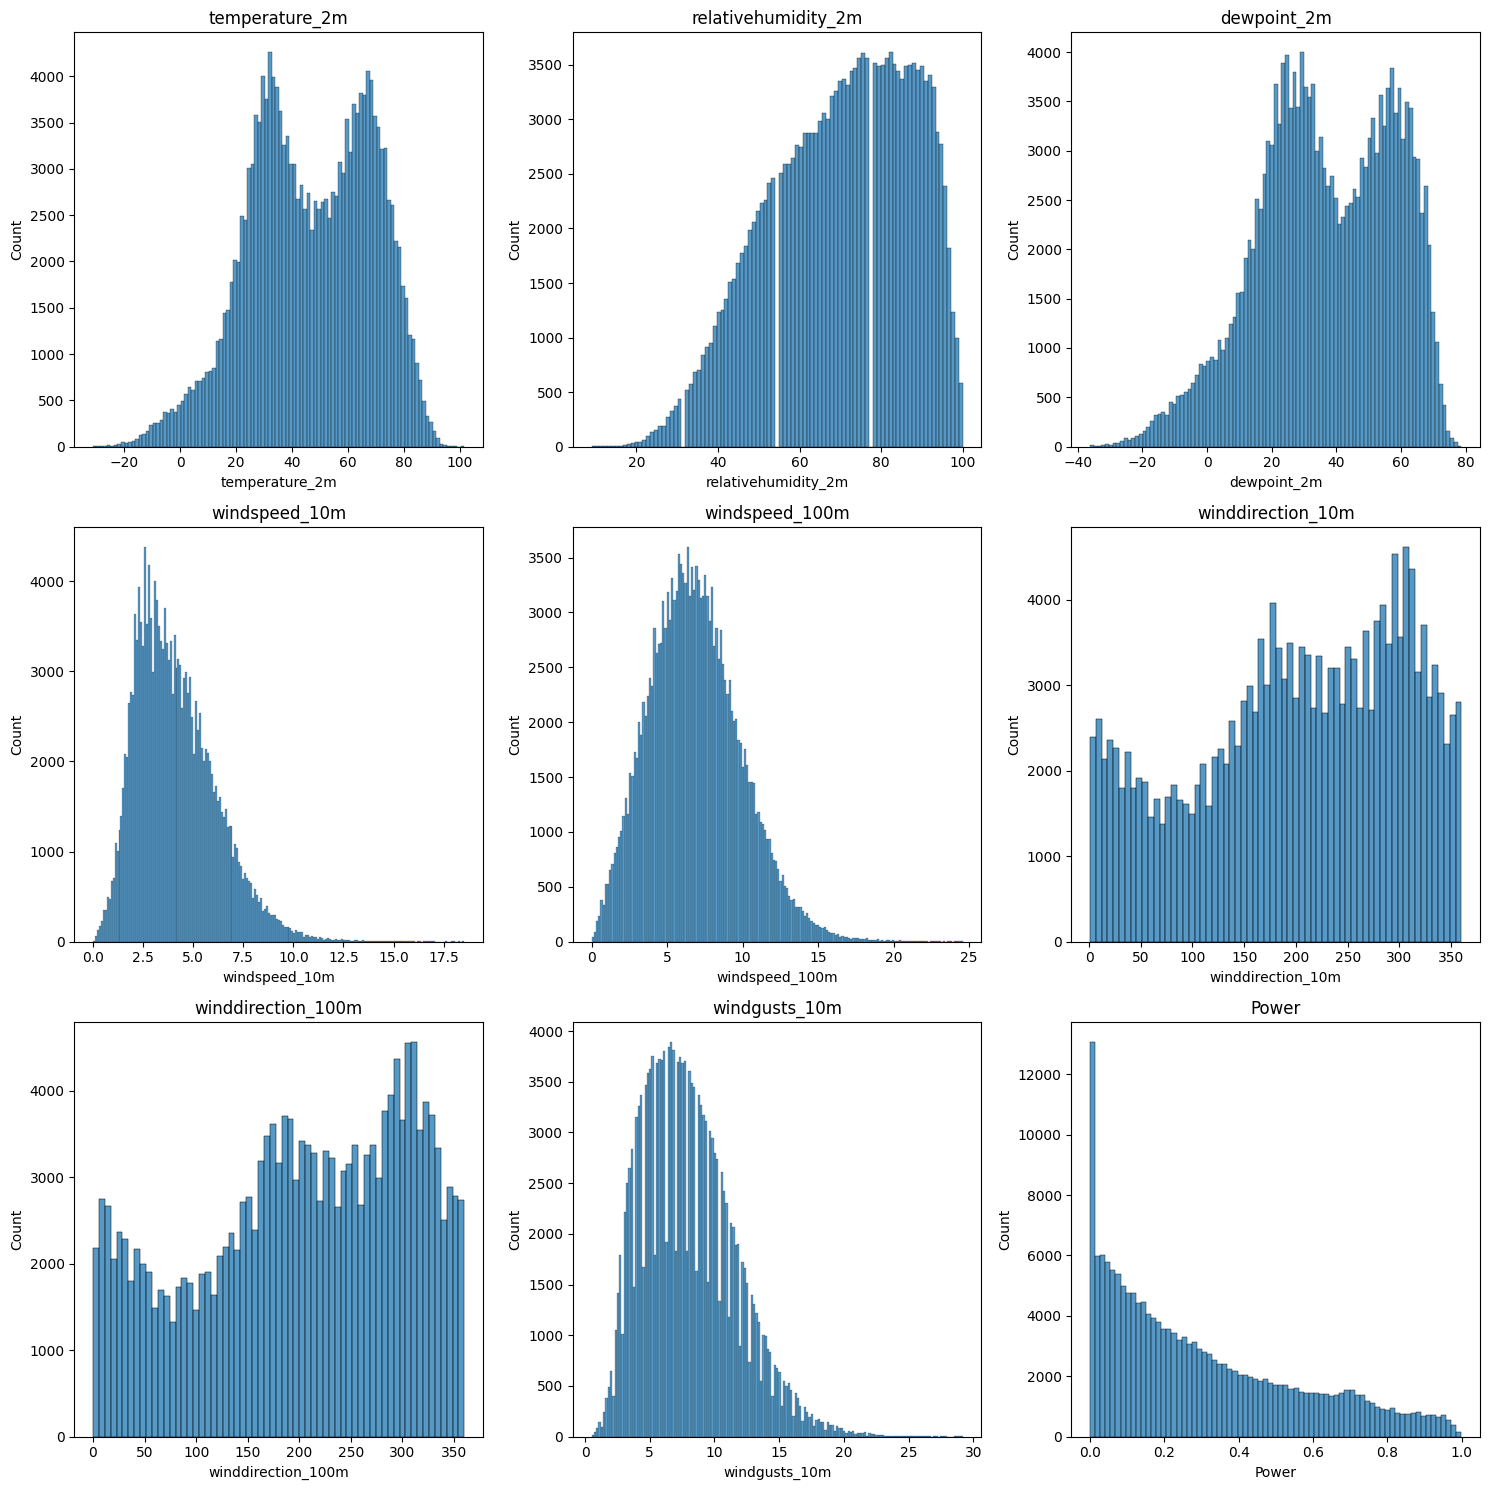

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_columns = merged_data.select_dtypes(include=['int64', 'float64']).columns

# Prepare subplots grid (adjust the rows/cols if you have more or fewer features)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Loop through the numerical columns and plot histograms
for i, col in enumerate(numerical_columns[:9]):  # Limit to 9 for 3x3 grid
    sns.histplot(merged_data[col], ax=axes[i])
    axes[i].set_title(col)

# Tight layout and show once after all plots are created
plt.tight_layout()
plt.show()


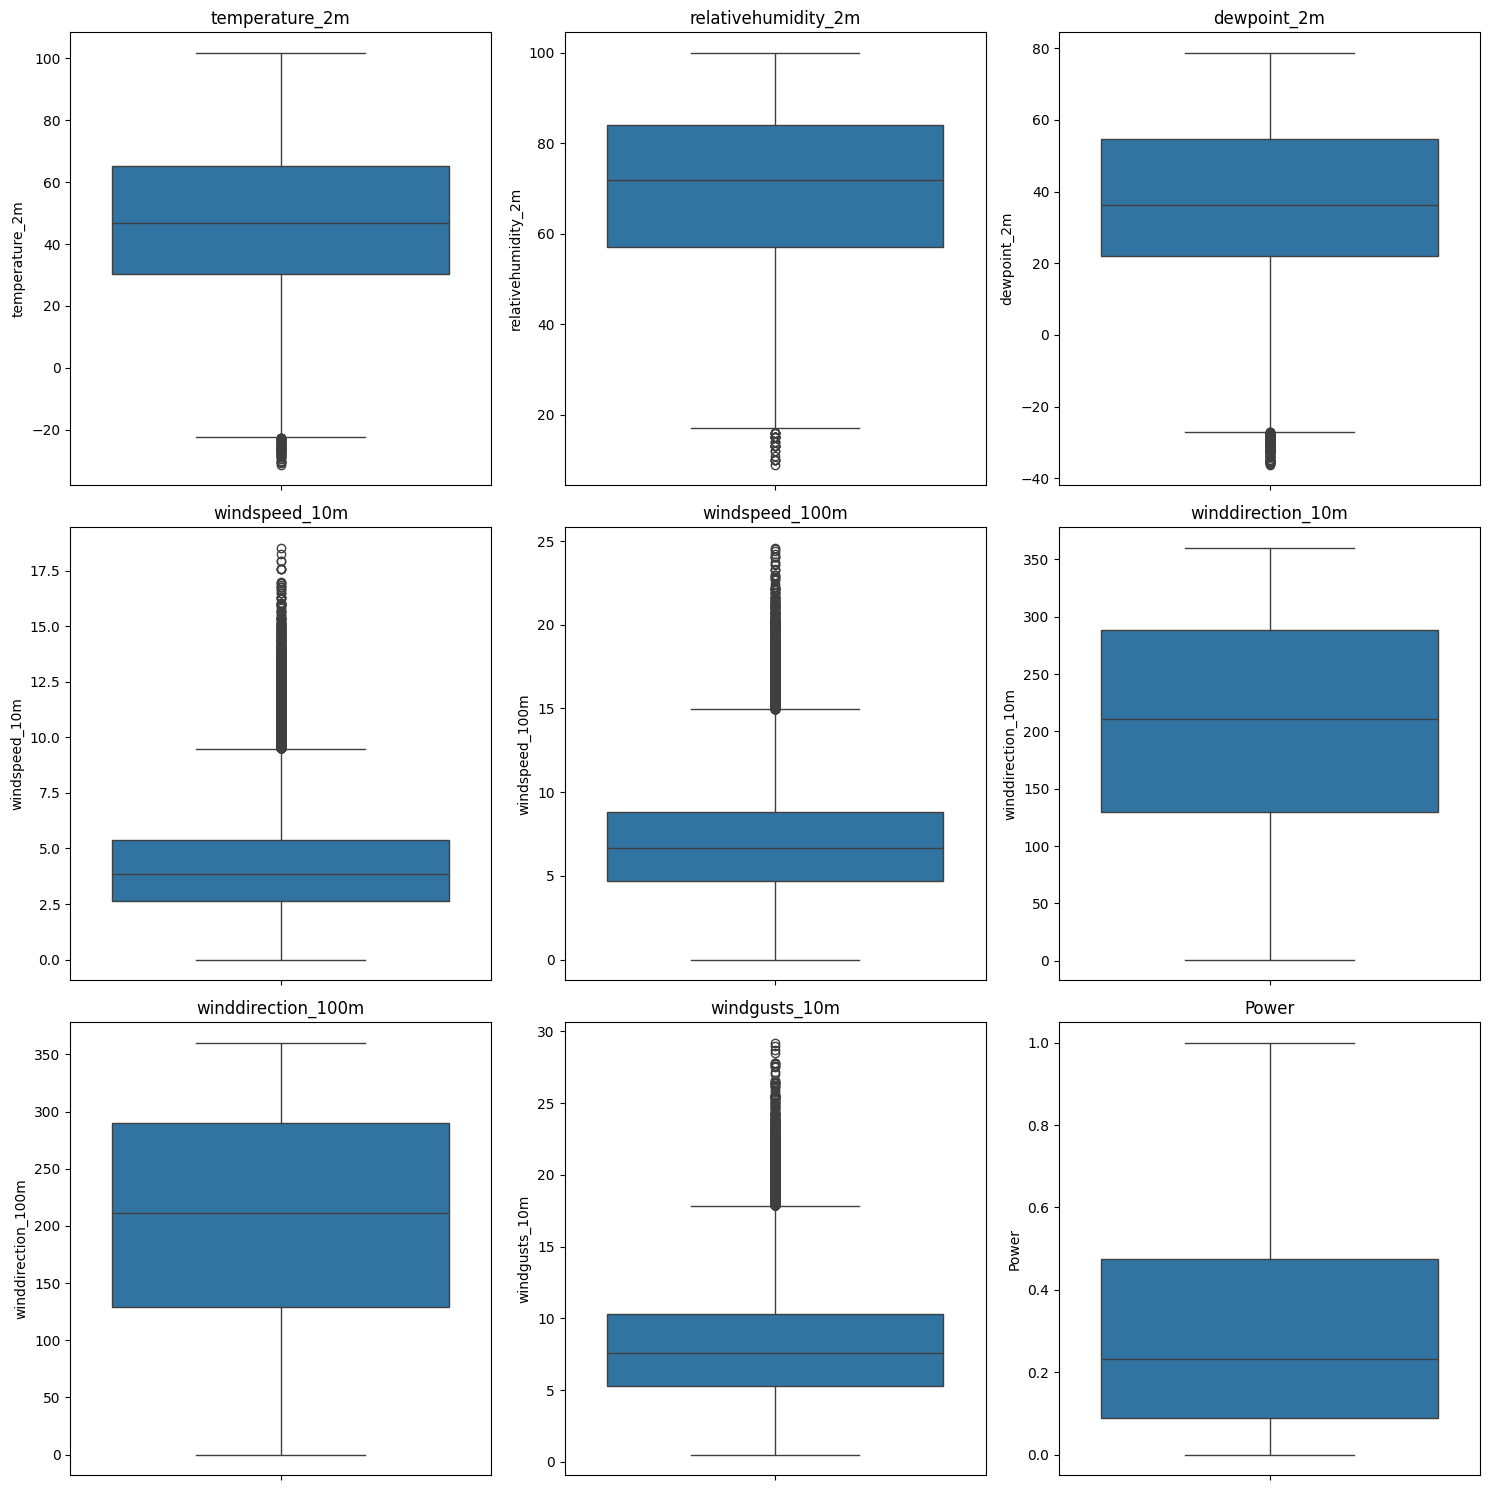

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_columns = merged_data.select_dtypes(include=['int64', 'float64']).columns

# Prepare subplots grid (adjust the rows/cols if you have more or fewer features)
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

# Loop through the numerical columns and plot histograms
for i, col in enumerate(numerical_columns[:9]):  # Limit to 9 for 3x3 grid
    sns.boxplot(merged_data[col], ax=axes[i])
    axes[i].set_title(col)

# Tight layout and show once after all plots are created
plt.tight_layout()
plt.show()


<Axes: xlabel='temperature_2m', ylabel='Power'>

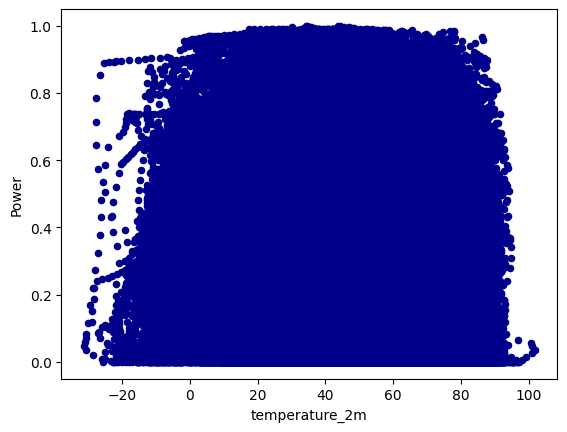

In [34]:
merged_data.plot.scatter(x='temperature_2m',y='Power',c='DarkBlue')

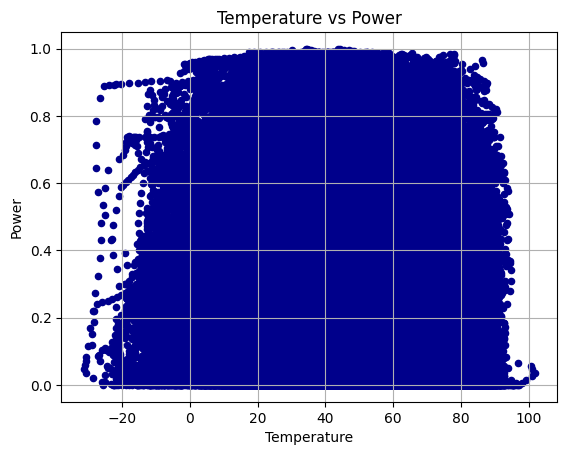

In [35]:
merged_data.plot.scatter(x='temperature_2m',y='Power',c='DarkBlue')
plt.xlabel('Temperature')
plt.ylabel('Power')
plt.title('Temperature vs Power')
plt.grid(True)

IndexError: index 8 is out of bounds for axis 0 with size 8

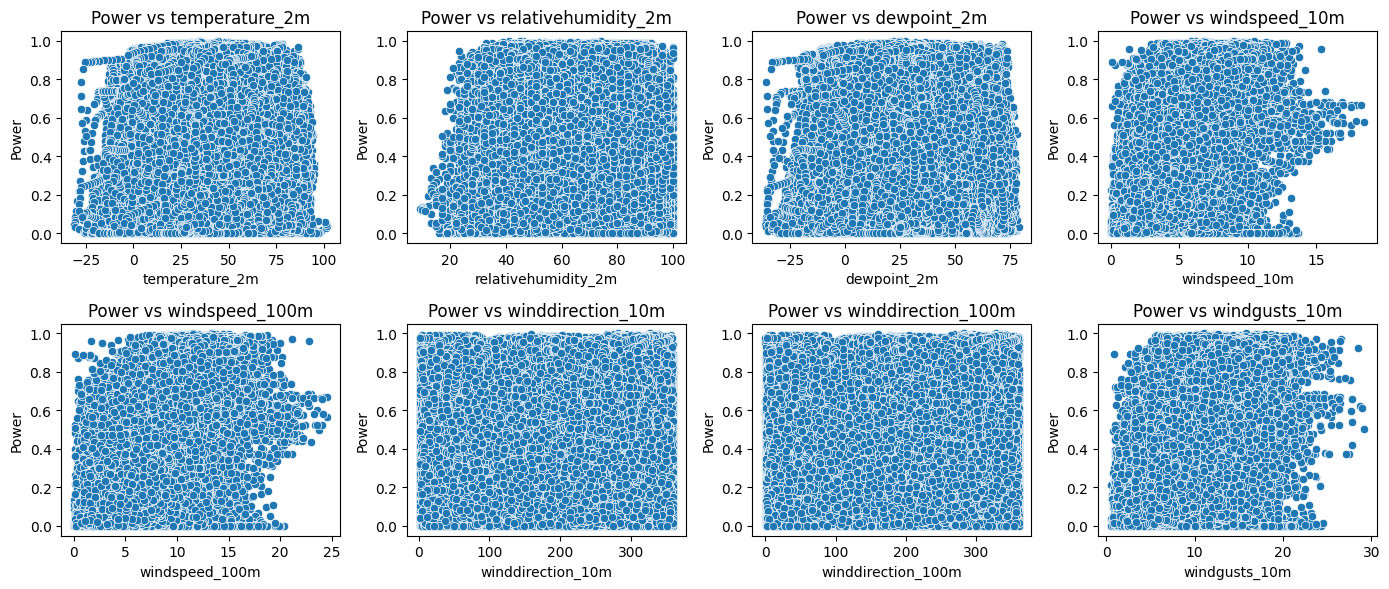

In [36]:
fig,axes=plt.subplots(2,4,figsize=(14,6))
axes=axes.flatten()
for i,col in enumerate (numerical_columns.drop('Power')):
    sns.scatterplot(x=col,y='Power',data=merged_data,ax=axes[i])
    axes[i].set_title(f'Power vs {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Power') 
    plt.tight_layout()
plt.show()

In [37]:
correlation=merged_data[numerical_columns].corr()
correlation

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power,Location_Location2,Location_Location3,Location_Location4
temperature_2m,1.000000,-0.173985,0.942370,-0.104589,-0.150422,-0.153010,-0.150095,0.010929,-0.141187,-0.103087,0.067397,0.004035
relativehumidity_2m,-0.173985,1.000000,0.160017,-0.162912,-0.034469,-0.107516,-0.113267,-0.270695,-0.031405,-0.035661,-0.062131,0.026702
dewpoint_2m,0.942370,0.160017,1.000000,-0.158822,-0.159134,-0.188577,-0.187519,-0.079240,-0.146789,-0.118606,0.047141,0.014839
windspeed_10m,-0.104589,-0.162912,-0.158822,1.000000,0.930667,0.141607,0.148542,0.929401,0.564750,0.153640,0.050620,-0.041757
windspeed_100m,-0.150422,-0.034469,-0.159134,0.930667,1.000000,0.146305,0.155401,0.827246,0.622108,0.131462,0.031916,-0.050542
winddirection_10m,-0.153010,-0.107516,-0.188577,0.141607,0.146305,1.000000,0.910205,0.139080,0.128059,0.040116,-0.039300,-0.012682
winddirection_100m,-0.150095,-0.113267,-0.187519,0.148542,0.155401,0.910205,1.000000,0.147822,0.136620,0.028766,-0.038087,-0.001027
windgusts_10m,0.010929,-0.270695,-0.079240,0.929401,0.827246,0.139080,0.147822,1.000000,0.568818,0.082875,0.015385,-0.055740
Power,-0.141187,-0.031405,-0.146789,0.564750,0.622108,0.128059,0.136620,0.568818,1.000000,-0.120096,0.009140,-0.117799
Location_Location2,-0.103087,-0.035661,-0.118606,0.153640,0.131462,0.040116,0.028766,0.082875,-0.120096,1.000000,-0.333333,-0.333333


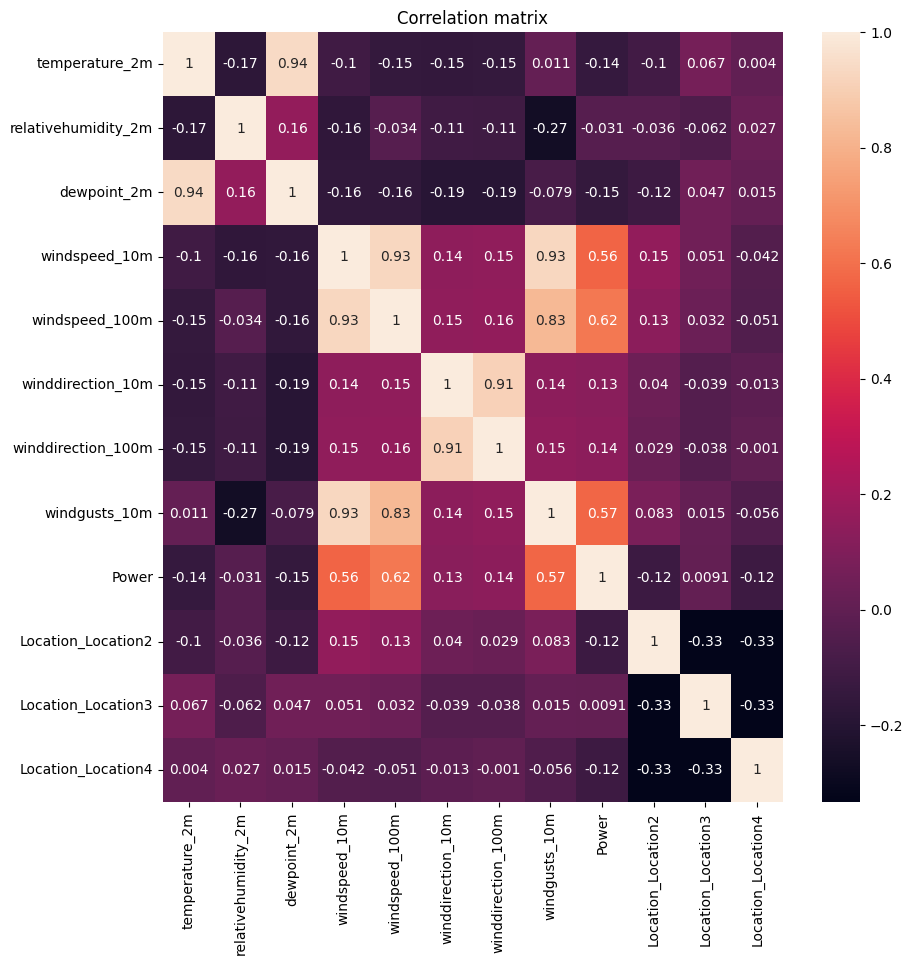

In [38]:
correlation=merged_data[numerical_columns].corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True)
plt.title("Correlation matrix")
plt.show()

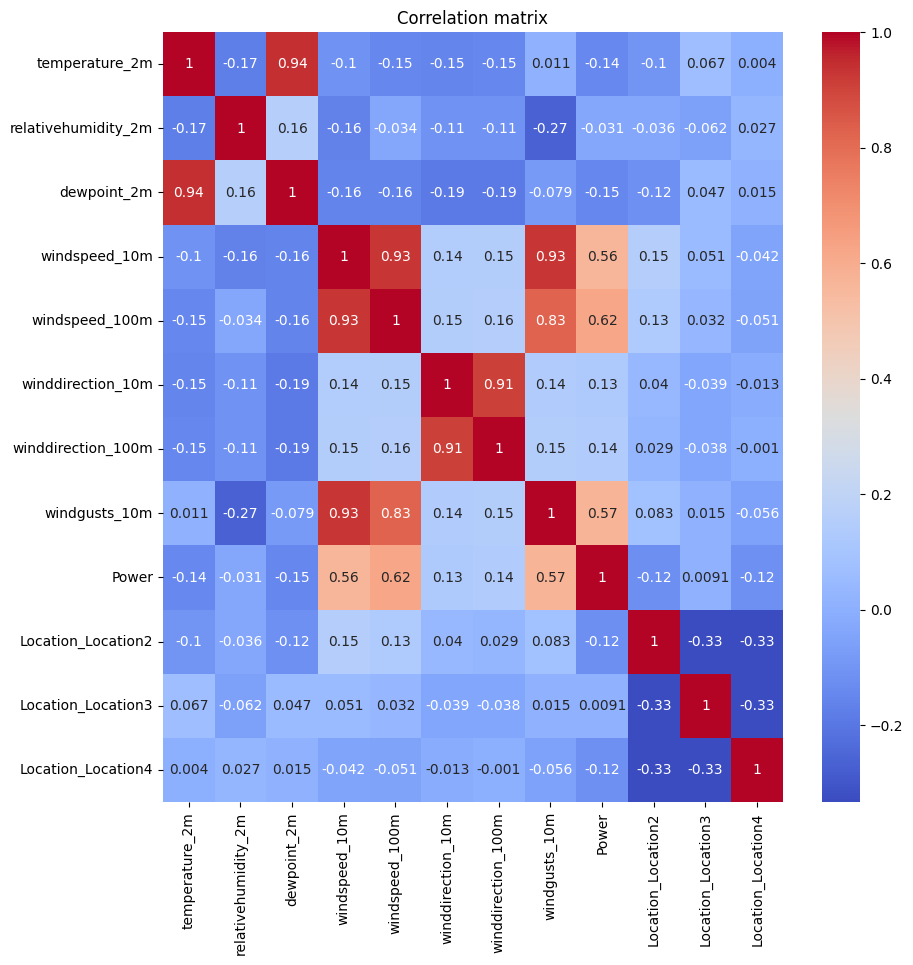

In [39]:
correlation=merged_data[numerical_columns].corr()
plt.figure(figsize=(10,10))
sns.heatmap(correlation,annot=True, cmap='coolwarm')
plt.title("Correlation matrix")
plt.show()

#WEEK3 DATA MODELING AND EVALUATE

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load your data
merged_data = pd.read_csv("merged_locations.csv")

# Create features and labels
X = merged_data.drop('Power', axis=1)
y = merged_data['Power']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle 'Time' column (convert to datetime and extract components)
X_train['Time'] = pd.to_datetime(X_train['Time'])
X_test['Time'] = pd.to_datetime(X_test['Time'])

X_train['year'] = X_train['Time'].dt.year
X_train['month'] = X_train['Time'].dt.month
X_train['day'] = X_train['Time'].dt.day
X_train['hour'] = X_train['Time'].dt.hour
X_train['minute'] = X_train['Time'].dt.minute

X_test['year'] = X_test['Time'].dt.year
X_test['month'] = X_test['Time'].dt.month
X_test['day'] = X_test['Time'].dt.day
X_test['hour'] = X_test['Time'].dt.hour
X_test['minute'] = X_test['Time'].dt.minute

# Drop the original 'Time' column
X_train = X_train.drop('Time', axis=1)
X_test = X_test.drop('Time', axis=1)

# Handle 'Location' column (one-hot encoding)
X_train = pd.get_dummies(X_train, columns=['Location'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Location'], drop_first=True)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Now your data is ready for model training



In [16]:
print(X_train.dtypes)


Time                    object
temperature_2m         float64
relativehumidity_2m      int64
dewpoint_2m            float64
windspeed_10m          float64
windspeed_100m         float64
winddirection_10m        int64
winddirection_100m       int64
windgusts_10m          float64
Location                object
dtype: object


In [19]:
# Train with Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Output the evaluation metrics
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")


Mean Squared Error (MSE): 0.031808387070636615
Mean Absolute Error (MAE): 0.13611251384358453
R-squared (R²): 0.5237871975162048


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load data
merged_data = pd.read_csv("merged_locations.csv")

# Drop non-numeric columns
merged_data = merged_data.drop(['Time', 'Location'], axis=1)

# Split features and target
X = merged_data.drop('Power', axis=1)
y = merged_data['Power']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
print(X_train.isnull().sum())  # Check for missing values
print(X_train.shape)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict using the trained model
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'RF MAE: {mae_rf}')
print(f'RF MSE: {mse_rf}')
print(f'RF R2 Score: {r2_rf}')


RF MAE: 0.1255895472888128
RF MSE: 0.028086348988047113
RF R2 Score: 0.5795109342251812


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Load data
merged_data = pd.read_csv("merged_locations.csv")

# Drop non-numeric columns
merged_data = merged_data.drop(['Time', 'Location'], axis=1)

# Split features and target
X = merged_data.drop('Power', axis=1)
y = merged_data['Power']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from xgboost import XGBRegressor
# Initialize the model
xgb_model = XGBRegressor()
# Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [3]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Read data
merged_data = pd.read_csv("merged_locations.csv")

# Preprocessing (drop non-numeric columns if needed)
X = merged_data.drop(['Power', 'Time', 'Location'], axis=1)
y = merged_data['Power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
from xgboost import XGBRegressor
xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f'XGB MAE: {mae_xgb}')
print(f'XGB MSE: {mse_xgb}')
print(f'XGB R2: {r2_xgb}')


XGB MAE: 0.12988336478857837
XGB MSE: 0.03004632897408683
XGB R2: 0.5501674921986677


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
merged_data = pd.read_csv("merged_locations.csv")

# Preprocessing (drop non-numeric columns if needed)
X = merged_data.drop(['Power', 'Time', 'Location'], axis=1)
y = merged_data['Power']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',  # Use MAE for evaluation
    cv=3,  # 3-fold cross-validation
    n_jobs=-1  # Use all available CPU cores
)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Best parameters and best score
print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best MAE: {-grid_search.best_score_}')

# Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)



print(f'Tuned Model Mean Absolute Error (MAE): {mae_tuned}')
print(f'Tuned Model Mean Squared Error (MSE): {mse_tuned}')
print(f'Tuned Model R^2 Score: {r2_tuned}')

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best MAE: 0.12856371330356983
Tuned Model Mean Absolute Error (MAE): 0.12782235787733578
Tuned Model Mean Squared Error (MSE): 0.029098756435013615
Tuned Model R^2 Score: 0.5643538818884896
